# Basic EDA: Loading data (read_csv), describe(), histograms and boxplots



## Workshop Plan

Three iterations, each with a different dataset:

| Iteration | Dataset | Rows | Type | Focus |
|-----------|---------|------|------|-------|
| 1 | Titanic | 891 | Mixed (categorical + numeric) | Survival patterns, outlier detection |
| 2 | Stock prices | 731 | Numeric time series | Price distributions, volatility |
| 3 | Weather | 731 | Numeric environmental | Correlations, seasonal patterns |

**Each iteration:**
- Load CSV, inspect shape/columns/summary stats
- Histograms with parameter exploration (bins, KDE, colors)
- Boxplots across features, identify outliers
- Correlation heatmap and scatter plots
- Observations and discussion

## Learning Objectives

By the end of this workshop, participants should be able to:

- Load and inspect datasets with `pd.read_csv()`, `.head()`, `.info()`, `.describe()`
- Detect missing values and understand data shapes
- Create histograms with parameter tuning (bins, KDE overlays, colors)
- Use boxplots to identify outliers and compare distributions
- Build correlation heatmaps and interpret relationships
- Apply these techniques to different data types and domains

## Setup: Download Datasets

This workshop requires three datasets. Run the cell below to automatically download them:

**Datasets:**
1. **Titanic** — Passenger survival data from seaborn public repository
2. **Stock Prices** — Simulated Apple stock daily data (2023-2024)
3. **Weather** — NYC weather data from Open-Meteo API (daily, 2023-2024)

All files will be saved to the `data/` folder in your working directory. If files already exist, they won't be re-downloaded.

In [5]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)

print("=" * 70)
print("DOWNLOADING DATASETS FOR WORKSHOP")
print("=" * 70)

# Titanic dataset
print("\n[1/3] Titanic dataset...")
try:
    if not os.path.exists("data/titanic.csv"):
        titanic = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
        titanic.to_csv('data/titanic.csv', index=False)
        print(f" Downloaded: {titanic.shape[0]} rows, {titanic.shape[1]} columns")
    else:
        print(" Already exists")
except Exception as e:
    print(f"   Error: {e}")

# Stock data (Apple synthetic)
print("\n[2/3] Stock price data (Apple AAPL)...")
try:
    if not os.path.exists("data/stocks_aapl.csv"):
        import numpy as np
        np.random.seed(42)
        dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
        n = len(dates)
        prices = 150 + np.cumsum(np.random.randn(n) * 2)
        stock_df = pd.DataFrame({
            'Date': dates,
            'Close': prices,
            'Volume': np.random.randint(50000000, 150000000, n),
            'High': prices + np.abs(np.random.randn(n) * 2),
            'Low': prices - np.abs(np.random.randn(n) * 2),
        })
        stock_df.to_csv('data/stocks_aapl.csv', index=False)
        print(f" Generated: {stock_df.shape[0]} rows, {stock_df.shape[1]} columns")
    else:
        print(" Already exists")
except Exception as e:
    print(f"   Error: {e}")

# Weather data (Open-Meteo API)
print("\n[3/3] Weather data (NYC)...")
try:
    if not os.path.exists("data/weather_nyc.csv"):
        import urllib.request
        import json
        
        url = "https://archive-api.open-meteo.com/v1/archive?latitude=40.71&longitude=-74.01&start_date=2023-01-01&end_date=2024-12-31&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
        with urllib.request.urlopen(url, timeout=10) as response:
            data = json.loads(response.read())
        
        weather_df = pd.DataFrame({
            'time': data['hourly']['time'],
            'temperature': data['hourly']['temperature_2m'],
            'humidity': data['hourly']['relative_humidity_2m'],
            'precipitation': data['hourly']['precipitation'],
            'wind_speed': data['hourly']['wind_speed_10m']
        })
        
        weather_df = weather_df.iloc[::24].reset_index(drop=True)
        weather_df.to_csv('data/weather_nyc.csv', index=False)
        print(f"  Downloaded: {weather_df.shape[0]} rows, {weather_df.shape[1]} columns")
    else:
        print("  Already exists")
except Exception as e:
    print(f"   Error (fallback to synthetic): {e}")
    # Fallback: create synthetic weather data
    try:
        np.random.seed(42)
        dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
        n = len(dates)
        weather_df = pd.DataFrame({
            'time': dates.astype(str),
            'temperature': 15 + 10 * np.sin(np.arange(n) * 2 * np.pi / 365) + np.random.randn(n) * 2,
            'humidity': 60 + np.random.randn(n) * 10,
            'precipitation': np.random.exponential(2, n),
            'wind_speed': 5 + np.random.exponential(1, n),
        })
        weather_df.to_csv('data/weather_nyc.csv', index=False)
        print(f" Generated (synthetic): {weather_df.shape[0]} rows, {weather_df.shape[1]} columns")
    except Exception as e2:
        print(f"   Fallback failed: {e2}")


DOWNLOADING DATASETS FOR WORKSHOP

[1/3] Titanic dataset...
 Already exists

[2/3] Stock price data (Apple AAPL)...
 Already exists

[3/3] Weather data (NYC)...
  Already exists


In [7]:
# Install dependencies as needed:
# pip install pandas seaborn matplotlib numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)



---

# ITERATION 1: TITANIC DATASET

Explore survival patterns, passenger demographics, and fare distributions.

## 1.1 Load and inspect Titanic data

In [12]:
# Load the dataset
df = pd.read_csv("data/titanic.csv")

print("=" * 60)
print("TITANIC DATASET")
print("=" * 60)
# print the shapes and the list of columns
print(f"columns: {list(df.columns)}")
print(f"shape: {df.shape}")
# print the head
print(df.head())
# print the info
print(df.info())
# print the description
print(df.describe())

TITANIC DATASET
columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataF

## 1.2 Histograms: Explore distributions

Numeric columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


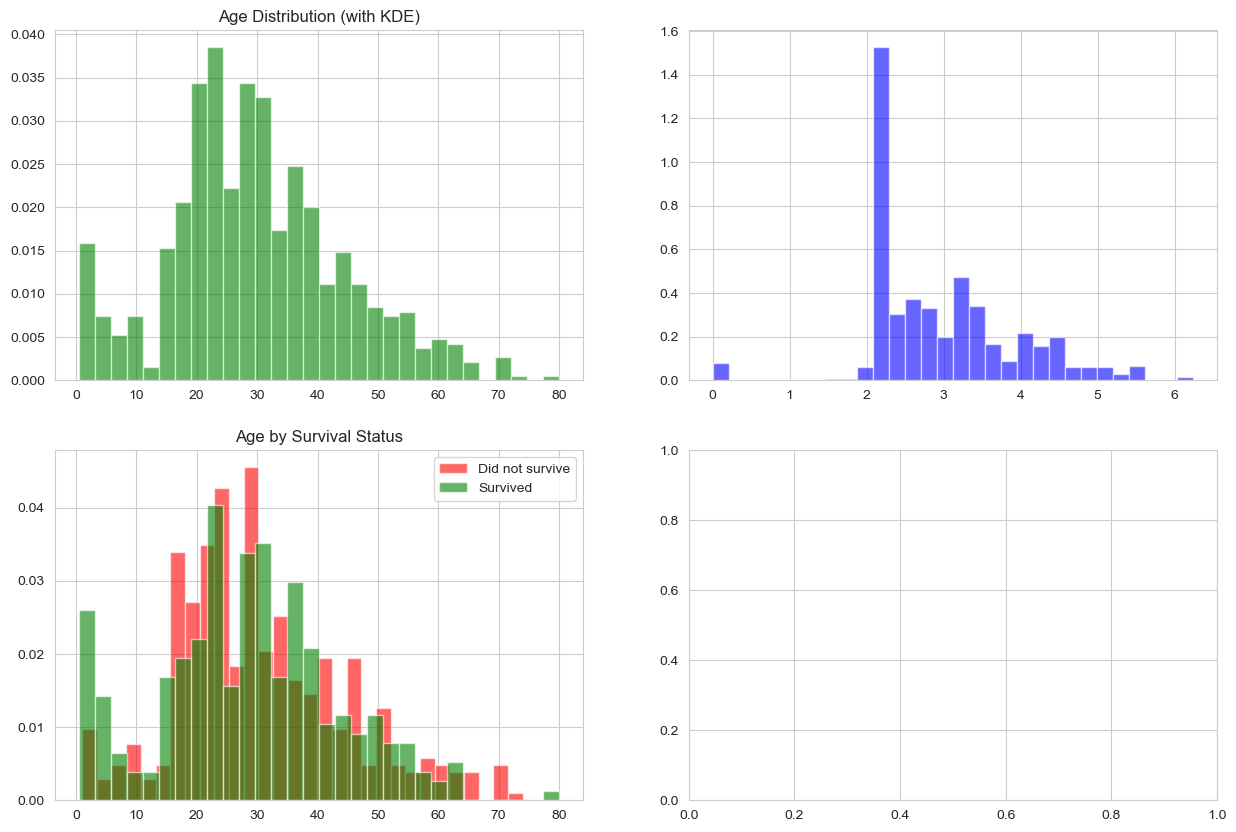

In [14]:
# Numeric columns for Titanic
numeric_cols_titanic = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns: {numeric_cols_titanic}")

# Create histogram grid with 4 subplots (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Flatten the axes array for easy indexing
axes = axes.flatten()
# Plot 1: Age (with KDE) set_title("Age Distribution (with KDE)")
axes[0].hist(df["age"].dropna(), bins=30, density=True, alpha=0.6, color='g')
# Plot 2: Fare (log scale) set_title("Fare Distribution")
axes[1].hist(np.log(df["fare"].dropna() + 1), bins=30, density=True, alpha=0.6, color='b')
axes[0].set_title("Age Distribution (with KDE)")
# Plot 3: Age by survival (hint use groupby and hist)
grouped_data = df.groupby("survived")["age"].apply(lambda x: x.dropna())
axes[2].hist(grouped_data[0], bins=30, density=True, alpha=0.6, label="Did not survive", color='r')
axes[2].hist(grouped_data[1], bins=30, density=True, alpha=0.6, label="Survived", color='g')
axes[2].set_title("Age by Survival Status")
axes[2].legend()

# Plot 4: Custom histogram exploration


#plt.tight_layout()
#plt.show()


## 1.3 Boxplots: Spot outliers and compare groups

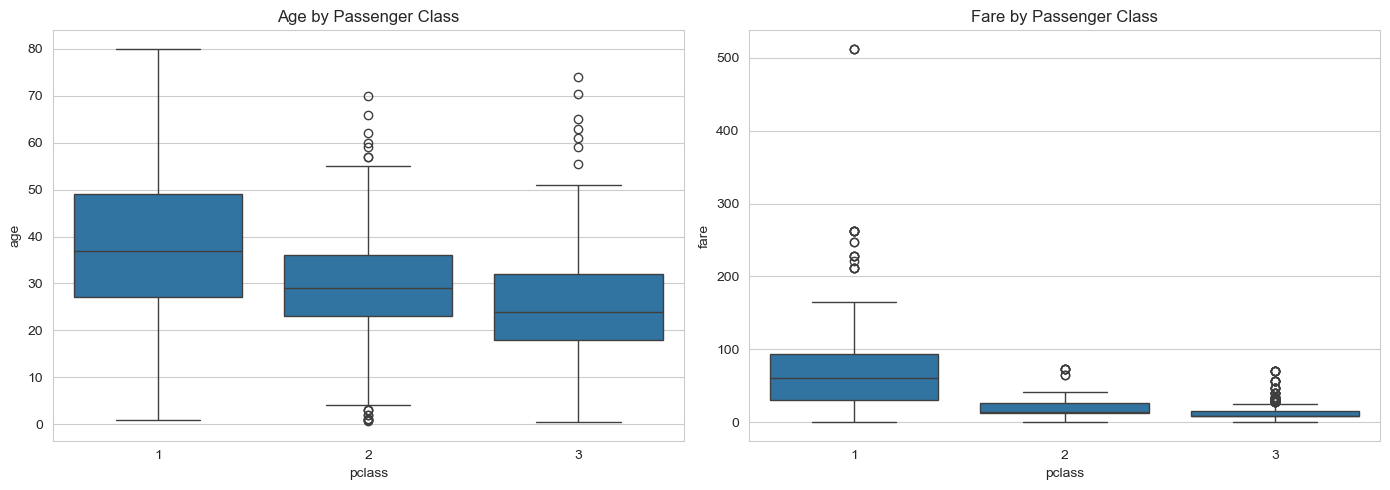

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Age by passenger class
sns.boxplot(x="pclass", y="age", data=df, ax=axes[0])
axes[0].set_title("Age by Passenger Class")

# Boxplot 2: Fare by passenger class
sns.boxplot(x="pclass", y="fare", data=df, ax=axes[1])
axes[1].set_title("Fare by Passenger Class")

plt.tight_layout()
plt.show()


(array([ 6., 54., 18., 36., 36., 13., 11., 11.,  9.,  2.,  0.,  0.,  5.,
         4.,  2.,  6.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  3.]),
 array([  0.     ,  17.07764,  34.15528,  51.23292,  68.31056,  85.3882 ,
        102.46584, 119.54348, 136.62112, 153.69876, 170.7764 , 187.85404,
        204.93168, 222.00932, 239.08696, 256.1646 , 273.24224, 290.31988,
        307.39752, 324.47516, 341.5528 , 358.63044, 375.70808, 392.78572,
        409.86336, 426.941  , 444.01864, 461.09628, 478.17392, 495.25156,
        512.3292 ]),
 <BarContainer object of 30 artists>)

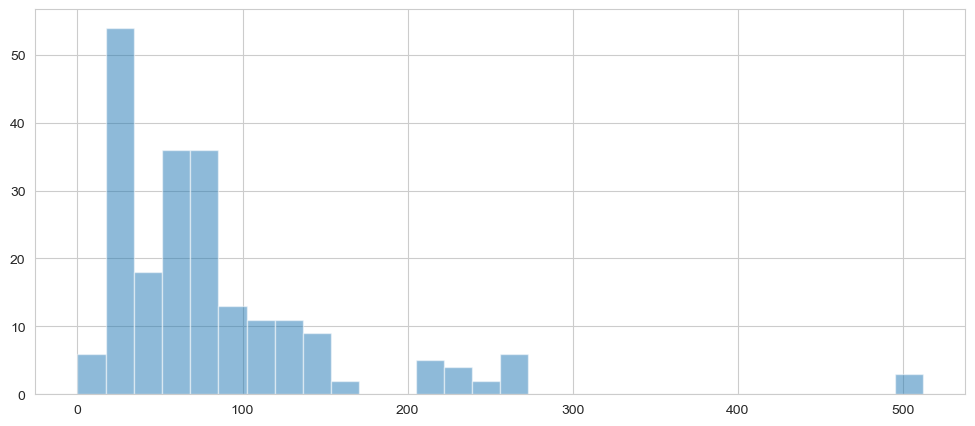

In [20]:
plt.hist(df[df['pclass'] == 1]['fare'].dropna(), bins=30, alpha=0.5, label='1st Class')

## 1.4 Correlations and relationships

In [ ]:
# Correlation heatmap


# Scatter: Fare vs Age with survival coloring


---

# ITERATION 2: STOCK PRICES DATASET

Analyze Apple stock daily prices, volume, and volatility patterns.

## 2.1 Load and inspect stock data

In [27]:
# Load the dataset
df_stock = pd.read_csv("data/stocks_aapl.csv")

print("=" * 60)
print("STOCK PRICE DATASET (Apple AAPL)")
print("=" * 60)
# print the shapes and the list of columns
print(f"columns: {list(df_stock.columns)}")
print(f"shape: {df_stock.shape}")
# maximum and minimum date
print(f"Date range: {df_stock['Date'].min()} to {df_stock['Date'].max()}")

print("\nFirst 5 rows:")
print(df_stock.head())


print("\nNumeric summary:")
print(df_stock.describe())
# Compute simple metrics
# .pct_change() calculates percent change between consecutive values
# Formula: (current - previous) / previous * 100
# Example: Close prices [150, 152, 151] → returns [NaN, 1.33%, -0.66%]
df_stock["Daily_Return"] = df_stock["Close"].pct_change() * 100
df_stock["Daily_Range"] = df_stock["High"] - df_stock["Low"]

print("\nFirst 5 rows with new metrics:")
print(df_stock[["Date", "Close", "Daily_Return", "Daily_Range"]].head())
print("\nDaily returns and range:")


STOCK PRICE DATASET (Apple AAPL)
columns: ['Date', 'Close', 'Volume', 'High', 'Low']
shape: (731, 5)
Date range: 2023-01-01 to 2024-12-31

First 5 rows:
         Date       Close     Volume        High         Low
0  2023-01-01  150.993428   70080673  152.950174  149.516167
1  2023-01-02  150.716900  148475024  150.844612  150.380790
2  2023-01-03  152.012277  124052985  152.253457  149.776245
3  2023-01-04  155.058336   56238795  155.847180  154.795420
4  2023-01-05  154.590030  131266262  155.444601  151.770642

Numeric summary:
            Close        Volume        High         Low
count  731.000000  7.310000e+02  731.000000  731.000000
mean   144.855128  9.876076e+07  146.489456  143.206285
std     12.875069  2.826497e+07   12.875493   12.973268
min    122.946109  5.022470e+07  123.861195  121.342503
25%    133.919312  7.480777e+07  135.715876  132.190435
50%    142.531698  9.771802e+07  144.150407  141.008785
75%    155.227837  1.238996e+08  156.929836  153.230854
max    181.2712

## 2.2 Histograms: Price and volatility distributions

Text(0.5, 1.0, 'Closing Price Distribution')

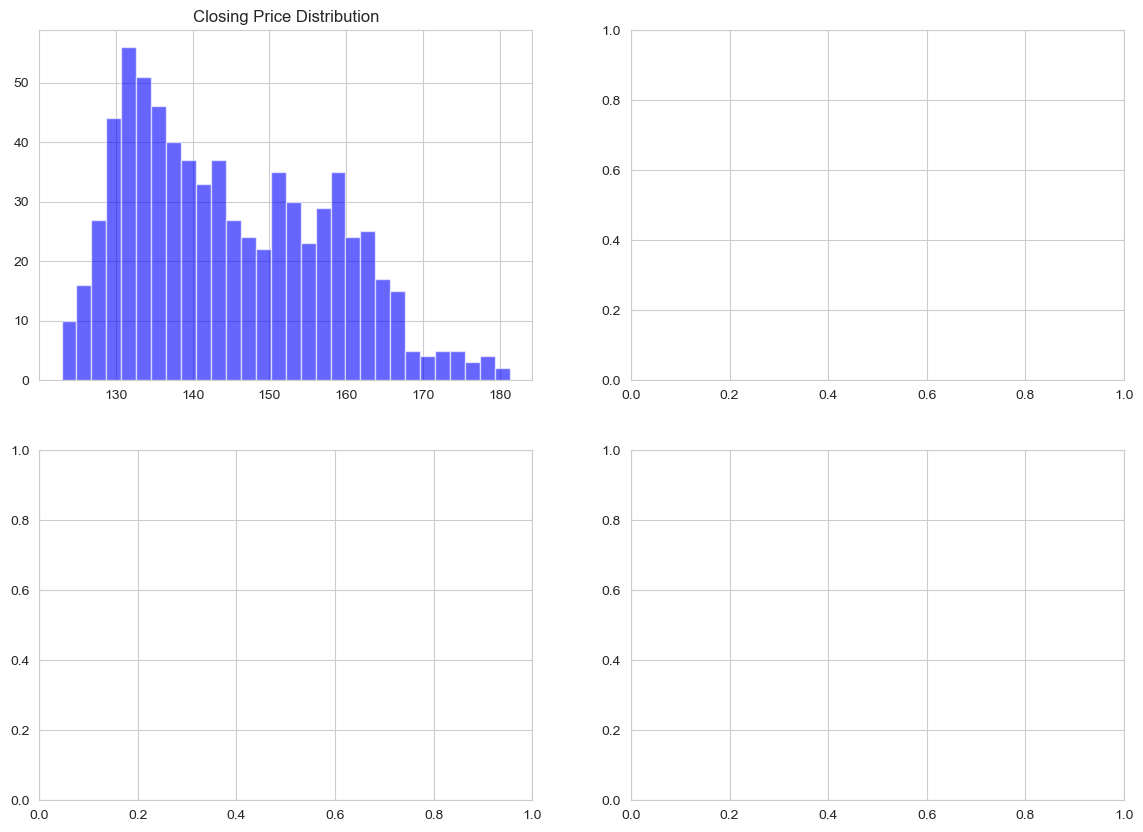

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Closing price distribution
axes[0].hist(df_stock["Close"].dropna(), bins=30, alpha=0.6, color='blue')
axes[0].set_title("Closing Price Distribution")


# Plot 2: Volume distribution (log scale)


# Plot 3: Daily returns


# Plot 4: Daily price range


#plt.tight_layout()
#plt.show()



## 2.3 Boxplots: Identify price and volume outliers

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Close price


# Boxplot 2: Volume


plt.tight_layout()
plt.show()


## 2.4 Correlations: Price components

In [ ]:
# Scatter: Volume vs Daily Range



---

# ITERATION 3: WEATHER DATASET

Analyze NYC temperature, humidity, precipitation, and wind patterns.

## 3.1 Load and inspect weather data

In [ ]:
# Load the dataset
df_weather = pd.read_csv("data/weather_nyc.csv")

print("=" * 60)
print("WEATHER DATASET (NYC)")
print("=" * 60)


print("\nFirst 5 rows:")

print("\nNumeric summary:")

print("\nMissing values:")


## 3.2 Histograms: Weather variable distributions

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Temperature 
#set_title("Temperature Distribution (°C)")


# Plot 2: Humidity set_title("Relative Humidity Distribution (%)")


# Plot 3: Precipitation
# Exclude zeros for better visualization
#set_title(f"Precipitation Distribution (non-zero days, n={len(precip_nonzero)})")

# Plot 4: Wind speed
#set_title("Wind Speed Distribution (m/s)")

#plt.tight_layout()
#plt.show()


## 3.3 Boxplots: Seasonal and extreme weather

In [ ]:
#fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Temperature


# Boxplot 2: Wind speed


#plt.tight_layout()
#plt.show()

---

# WRAP-UP

## Key Takeaways

1. **Data Inspection is critical**: Always check shape, types, and missing values first.
2. **Multiple histograms reveal patterns**: Different datasets show different distributions (bimodal, skewed, uniform).
3. **Boxplots quickly identify outliers**: Use them for domain understanding and data quality checks.
4. **Correlations guide further analysis**: Strong correlations suggest relationships worth investigating.

## Next Steps

- Clean data (handle missing values, outliers)
- Group and aggregate (e.g., by survival, month, city)
- Build predictive models
- Create time series analysis (stocks, weather)
- Perform statistical tests on relationships

---

**Workshop Complete!**
Try running each iteration independently with your own questions in mind.

# Basic EDA: Loading data (read_csv), describe(), basic histograms and boxplots in Matplotlib/Seaborn

This notebook is designed as a 2.5-hour workshop for introductory exploratory data analysis.
It focuses on loading a CSV dataset, inspecting the data, computing summary statistics, and creating basic visualizations with Matplotlib and Seaborn.

## Workshop Plan (120 minutes)

Three 40-minute iterations, each with a different dataset:

| Iteration | Dataset | Time | Focus |
|-----------|---------|------|-------|
| 1 | Titanic (891 rows, mixed) | 40 min | Survival patterns, outliers |
| 2 | Stock prices (731 days) | 40 min | Time series, volatility |
| 3 | Weather (731 days) | 40 min | Correlations, distributions |

**Each 40-minute iteration:**
- 5 min — Load CSV, inspect shape/columns/summary
- 15 min — Histograms with parameter exploration (bins, KDE, colors)
- 10 min — Boxplots across features, identify outliers
- 8 min — Correlation and scatter plots
- 2 min — Discussion and observations


## Learning Objectives

By the end of this workshop, participants should be able to:

- Load a dataset from CSV using `pandas.read_csv()`
- Inspect dataset shape, columns, and data types
- Use `describe()` and other summary functions for numeric and categorical data
- Create histograms and boxplots with Matplotlib and Seaborn
- Identify outliers and distribution shapes
- Compute and visualize correlations between numeric features

In [ ]:
# Install dependencies as needed:
# pip install pandas seaborn matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
csv_path = "data/Exercise1.csv"
df = pd.read_csv(csv_path)

df.head()

## 6. Wrap-up and next steps

Suggested next steps:
- Clean missing values and duplicate rows
- Explore categorical values and group summaries
- Build pair plots or more advanced visualizations
- Start feature engineering for modeling

For the workshop, allow time for participants to ask questions, review their plots, and practice with a second dataset.